<a href="https://colab.research.google.com/github/UraZhang119/APEX-final/blob/main/Copy_of_PBL0_glucose_ode_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PBL#0: From Conceptual Understanding to Mathematical Simulation

**Learning goals:**
1. Understand and solve single-variable and coupled ordinary differential equations (ODEs) for blood glucose regulation and mass accounting.
2. Compare the analytical solution (when possible) to integrators to build intuition about numerical error.  
3. Extend to the coupled glucose–insulin system and simulate numerically with `scipy.integrate.solve_ivp` to understand the role of parameters in modeling results.

Now we are getting to the point in the course where conservation and accounting equations are no longer abstract concepts and we can model them as numerical entities. Today's discussion will focus on how to use the Python ODE solvers to solve single and multiple simultaneous differential equations.

## One equation ODE solving

Let's say that we have a differential equation with the form $$\frac{dy}{dt} = f(t,y,\theta)$$ where we call $t$ the independent variable (time here) and $y$ the dependent variable. If the function $f$ is purely in terms of time, we call this a pure-time ordinary differential equation. $\theta$ corresponds to the parameter(s) that are used in the equation that we may simulate, which can be time-varying or constant. We will see some of these in the course as chemical flow rates in the zeroth order or in some predicted models of disease growth, but they're not too common in the scheme of solving ODEs.


## What happens to glucose in our body?

To begin, let's think about blood glucose levels in a single-compartment model:

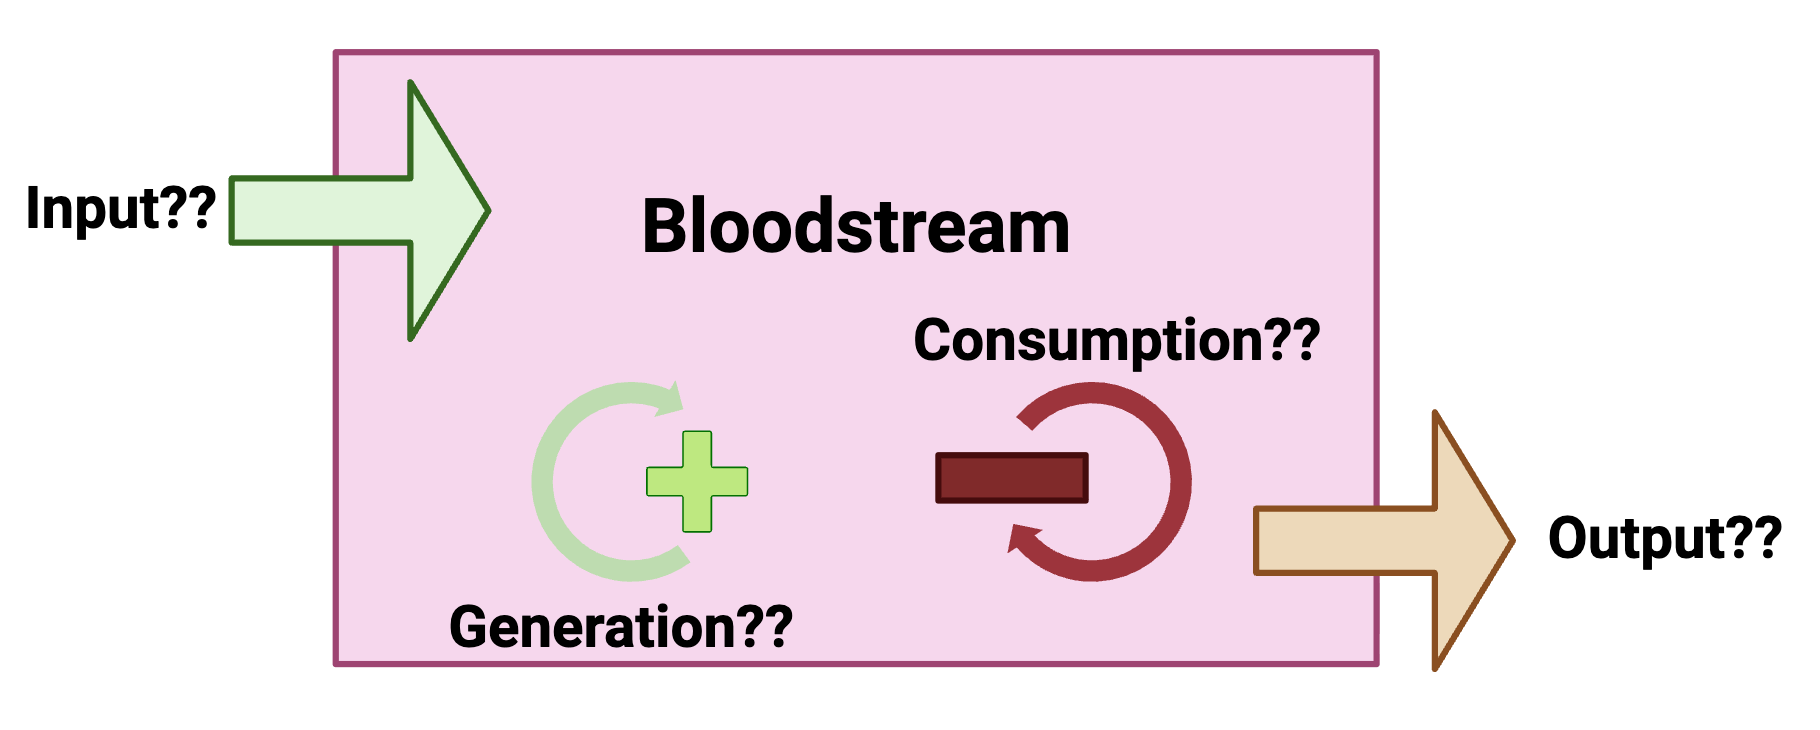

In your groups, determine which terms you would like to include in your mass acounting equation?

**Double-click on this to open the Markdown window and type your response!**

# Simplified one-compartment model of blood glucose

Let's start with a simple model that just looks at how glucose is eliminated from the bloodstream upon a constant infusion of glucose. First, we can assume that a patient is receiving a constant rate of glucose infused in the bloodstream, perhaps due to hospitalization. Let's model this as $$\dot{G}_{\text{in}} = +m(t) = m_0$$ We could possibly model as a time-varying function (i.e. eating food every 4 hours), but we will simplify to a constant glucose intake rate $m_0 > 0$ grams/min. As insulin acts on cells, it promotes glucose uptake in energy-hungry cells (e.g., muscle cells, neurons, etc.) and it will uptake based on the amount of available blood glucose. Thus, we can say this is a *first-order elimination* process. $$\dot{G}_{\text{out}} = -aG$$ Therefore, assuming no generation or consumption of glucose in the bloodstream, we have a final *differential* accounting equation $$\frac{dG}{dt} = \dot{G}_{\text{in}} - \dot{G}_{\text{out}} = m_0 - aG$$





**SOLVE THIS BY HAND** (Hint: You can do via separation of variables or by an integrating factor)

### <-Click this arrow to see solution

$$G(t) = \frac{m_0}{a} + \left( G_0 - \frac{m_0}{a} \right) e^{-a t}$$

Let's say that $G_0 = 90$ mg/dL as initial glucose, an infusion rate of $m_0 = 1.5$ mg/dL/min and $a=0.02$ min$^{-1}$. Plot this solution using `matplotlib`

### Importing libraries for solving ODEs and graphing

We'll need a few important packages. Some you know of, others may be a bit new to you.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
## Parameters should be easily defined, and comments are important for unit and dimensional analysis
G0 = 90.0   # mg/dL (initial glucose level)
m0 = 1.5    # mg/dL/min (constant production/input rate)
a = 0.02    # 1/min (clearance rate constant)
tspan = np.linspace(0,300,100) # minutes

def G_function(t, G0, m0, a):
    return ##TYPE FUNCTION IN HERE##

plt.figure(figsize=(8,4),dpi=300) # use dpi = 300 to make figures export better for reports!
plt.plot(tspan, G_function(tspan, G0, m0, a), label='Analytic Solution', linewidth=2)
plt.xlabel('t (min)')
plt.ylabel('Blood glucose levels (mg/dL)')
plt.legend()
plt.title('Analytic Solution for dG/dt = $m_0 - aG$')
plt.show()

You can learn many things from this graph and leverage many `numpy` commands to help find **quantitative** results that are necessary for your PBL reporting. Work with a neighbor to determine these results:

**Questions for you**:


1.   What is the *steady-state* value of blood glucose in this model? You can estimate from where you see the plateau occur, or can you analytically solve for this?




In [ ]:
#CODE/ANSWER HERE

2.   At what time from $t=0$ min does the halfway point occur? We can consider this the *half-life* of glucose elimination. Solve for this using different commands or by visual eye.

In [ ]:
# Task: estimate the half-life of glucose decay

# Step 1: compute the halfway glucose value
# TODO: replace None with the correct value
G_half = None

# Step 2: evaluate G(t) across the time span
G_values = G_function(tspan, G0, m0, a)

# Step 3: find the time when G(t) is closest to G_half
# TODO: find the index where |G(t) - G_half| is minimized
half_life_index = None

# Step 4: extract the half-life time
# TODO: extract the corresponding time from tspan
half_life_time = None

print(f"Estimated glucose half-life: {half_life_time:.1f} minutes")

In [ ]:
# Target glucose value for half-life
half_G = None  # mg/dL

# Step 1: evaluate glucose across time
# TODO: compute G(t) over tspan using G_function
G_values = None

# Step 2: find index of closest glucose value to half_G
# TODO: use np.abs and np.argmin
idx = None

# Step 3: extract corresponding time and glucose value
# TODO: use idx to extract from tspan and G_values
t_closest = None
G_closest = None

print(f"Estimated half-life time: {t_closest:.1f} minutes")
print(f"Glucose at that time: {G_closest:.2f} mg/dL")

These are all important results that you should keep a track of, and you should consider how you would write up results related to this simulation. More on this in a few minutes.

## Coupled ODEs and solvers in Python

We can solve using something like a forward Euler method (in case you forgot that, Dr. Wallace was kind enough to give me this video as a reminder :) [Forward Euler Method from BME244L](https://duke.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=1fb3a4a3-48c6-4ac9-9dc4-b1d4014f7cc9)

With a simple, solvable, one-equation model, this works. But we are getting into some more complicated models soon, where we will want better algorithms to solve these systems.

We will use the command `solve_ivp` to solve ODE initial value problems. Let's start by importing the necessary package:

##Let's work to calculate a few time points by hand using the Euler Method

In [ ]:
from scipy.integrate import solve_ivp

Here is the code on how we would solve the simple blood glucose model using `solve_ivp` and what each step does:

In [ ]:
def f(t,y,c):
    G = y
    dGdt = c[0] - c[1]*G
    return dGdt

tspan = np.linspace(0,300,100)
yinit = [90]
#c is the constants vector that will be useful later on
c = [1.5, 0.02] # c[0]=m0 and c[1]=a
rtol = 1e-5 #don't change for now

sol = solve_ivp(lambda t, y: f(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)

print(sol)

**The Differential Equation Function**

The function `def f(t, y, c):` defines the rate of change of blood glucose.

* `t` represents time (in minutes).
*	`G = y` is a Python list that stores the current value(s) of the system based on the number of differential equations in the model.
* `dGdt` corresponds to the blood glucose differential accounting equation to solve for the G(t) function.
* `c` is a list of model constants that you define.


**Time Span of the Simulation**

`tspan` is the same as above to define the simulation window

**Initial Condition(s)**

The variable `yinit` sets the initial blood glucose level that we previously defined as $G(0) = 90$ mg/dL

The value is stored inside a list because `solve_ivp` is designed to handle systems of equations, even when there is only one equation. You will need this for the coupled ODEs and define each list element.

**Model Parameters**

The list `c = [1.5, 0.02]` stores the constants used in the model:
* `c[0] = 1.5`$=m_0$ is the glucose input rate from before.
* `c[1] = 0.02`$=a$ is the glucose removal rate constant.

Keeping parameters in a separate list makes the model easier to modify and extend later. You may also want to define each constant separately and then concatenate into a constants vector if needed.

**Solving the Model Numerically**

The function `solve_ivp` is used to compute the numerical solution. A lambda anonymous function is used to pass the parameter list `c` into the differential equation function. The solver integrates the equation from the start to the end of the time span and returns the solution at the specified time points.

The result is stored in the object `sol`, which contains both the numerical solution and diagnostic information. In particular:
* `sol.t` contains the time values.
* `sol.y[0]` contains the blood glucose concentration over time. When there are multiple ODEs, `sol.y[1]`,`sol.y[2]` etc. will access the other outputs.
* `sol.success` indicates whether the solver completed successfully.

Try to plot this function against the analytic solution we generated earlier to see if they match up! Talk about them with your partner.

In [ ]:
## Plot the solution here! You can probably borrow 95% of the code from above...

plt.figure(figsize=(5,3),dpi=300)
plt.plot(tspan, G_function(tspan, G0, m0, a), label='Analytic Solution', linewidth=2)
plt.plot(sol.t, sol.y[0], 'ko', markevery=5, label='G(t) via ODE solver')
plt.xlabel('t (min)')
plt.ylabel('Blood glucose levels (mg/dL)')
plt.legend()
plt.title('Comparing analytic and solve_ivp solutions')
plt.show()



## Exploring parameters and response variables

You've already solved for some useful responses above, but one important feature of PBL and model assessment is exploring how changing parameters in a model leads to different outcomes. We often refer to this as **parametric analysis**. In looking at the model equation $\frac{dG}{dt} = m_0 - aG$, you can make *qualitative* good guesses as to what would happen to steady state levels of glucose or time to steady state based on changing parameters, but it is better to graphically visualize this so you can *quantitatively* describe the results in your reports

In [ ]:
plt.figure(figsize=(8,4),dpi=300)

a = 0.02
m0 = [0, 1, 2, 3, 4, 5]
for x in m0:
  plt.plot(tspan, G_function(tspan, G0, x, a), label=f"$m_0 = {x}$", linewidth=2)

plt.xlabel('t (min)')
plt.ylabel('Blood glucose levels (mg/dL)')
plt.legend(loc='best')
plt.title('Analyzing time series of blood glucose in response to changing $m_0$ values')
plt.show()

**Do the same thing for different values of $a$ in the model here**

In [ ]:
### Insert code here

**Describe the results in a couple of sentences. Look to provide quantitative and qualitative findings**

## Modeling insulin dynamics

In reality, we know that glucose uptake into cells is not truly a first-order reaction, but instead mediated by insulin levels that are secreted as a result of higher glucose. Let's make some modifications to our model and include insulin dynamics.

The elimination rate $a$ really should be in terms of insulin levels $I(t)$ and an *insulin sensitivity* parameter $s$ multiplied together: $$\frac{dG}{dt} = m_0 - s I G$$

We are now dealing with a *coupled* differential equation here, and we need to know the concentration of insulin. Working with your neighbor, and knowing what you know about insulin and blood glucose, ask yourselves the following:


1.   Where does insulin come from? Is this from the bloodstream or from somewhere else?
2.   Is insulin production constant, or is it dictated by physiological factors? If so, which one(s) is/are most important?
3.   What about insulin elimination? How would you best model this?

In answering these questions, you should come up with your best possible accounting equation for blood insulin levels

**Double-click here to type your thoughts on what the model equation should look like, then click on 1 cell hidden to show possible model equations**



*A* great starting equation would be: $$\frac{dI}{dt} = qB-\gamma I $$ where we account for the secretion rate of insulin $q$ from beta cells $B$. This probably gets things started, but aren't beta cells going to respond to glucose levels? That may mean we need to factor in some type of logical operation or function that corresponds to **hypoglycemia** vs. **hyperglycemia**. As a reminder:

*   Hypoglycemia: $G < 70$ mg/dL
*   Hyperglycemia: $G > 125$ mg/dL
*   Normoglycemia: $G$ between these two values

Let's apply some function $f(G)$ that accounts for these values and maximizes the production/input rate at high glucose $f(G>125) = 1$, low glucose $f(G<70)=0$, and maybe an intermediate value of $f(70<G<125) = 0.5$. This modifies our equation to: $$\frac{dI}{dt} = qBf(G)-\gamma I $$

This should work out, if glucose levels are high, we would expect a higher rate of insulin production. If glucose is low, then we shouldn't have insulin production. We keep the insulin elimination easy with a rate constant $\gamma$ with units of min$^{-1}$

Common units for insulin are in microunits, where in general, 1 unit of insulin lowers your blood sugar by about 50 milligrams per deciliter (mg/dL). This means that $q$ has units of $\mu$U/mL/min. $s$ has units of mL/($\mu$U*min). $B$ is an arbitrary value of beta cell activity, which we will leave as dimensionless for now.

## Solving coupled ODEs with `solve_ivp`

Can you see how to modify the above code with two equations? We will want to add a new line for the $\frac{dI}{dt}$ equation and appropriate constants and variables. See the starting code and make the modifications as you can:

$$\frac{dG}{dt} = m_0 - s I G$$
$$\frac{dI}{dt} = qBf(G)-\gamma I $$

In [ ]:
def insulin_threshold(G):
  ### Write a logic tree to build this into the code!


def f(t, y, c):
    """
    ODE system:
      y[0] = G (glucose, mg/dL)
      y[1] = I (insulin, arbitrary units)
    Parameters are passed explicitly via args to solve_ivp.
    """
    G, I = y
    dGdt = ##MODIFY THESE LINES##        # c[1] = s (different than a)
    dIdt = ##MODIFY THESE LINES##
    return [dGdt, dIdt]

# NB: You can also just define m0, s, q, B, gamma in the ODE above if you like!

tspan = np.linspace(0,300,1000)
yinit = [90, 10]

## Parameters
m0 = 1.5 # mg/dl/min
s = 0.01 #
q = 0.2  #
B = 1.0  #
gamma = 0.15

c = [m0, s, q, B, gamma]
rtol = 1e-5 #don't change for now

sol = solve_ivp(lambda t, y: f(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)

print(sol)

plt.figure(figsize=(8,4),dpi=300)
plt.plot(sol.t, sol.y[0], 'k-', label='G(t) with insulin via ODE solver')
plt.xlabel('t (min)')
plt.ylabel('Blood glucose levels (mg/dL)')
plt.legend()
plt.title('Incorporating insulin dynamics into blood glucose levels')
plt.show()

Now that we have these two models compared, how might you describe the result differences between the incorporation of insulin dynamics vs. without? Has your model become more realistic? What issues do you still see with this model?

**DOUBLE-CLICK this cell to open and type up your thoughts**

**For your PBL0 assignment, you will need to perform parametric analysis to make your results more reasonable such that for a healthy person, you can get the steady-state glucose levels to a reasonable value**

## Modeling more realistic inputs of glucose

There are very few situations where we are on a constant glucose intake as we've described above. We eat at certain periods of the day and would normally have spikes and dips, but hopefully return to a normoglycemic level. One possible way that we assess a person's risk of diabetes is through a **glucose oral tolerance test.** A patient would drink a 75 g solution of glucose and observe the blood glucose levels over a few hours. A patient's glucose levels at two hours post-ingestion can indicate risk, such that normal blood sugar is below 140 mg/dL, prediabetes is 140–199 mg/dL, and diabetes is 200 mg/dL or higher after this test. Let's simulate this:

In [ ]:
def G_input(t, total_g,time_input):
    """
    Input glucose for OTT in short span:
      t = time as an input
      total_g = amount of glucose in mg (75 g = 75000 mg)
      time_input = time of drinking or extend to needed kinetics
    """
    rate = ##MODIFY THIS RATE##     # 50 dL = volume, mg/dL per min during pulse
    if 0 <= t <= time_input:
        return rate
    return 0.0

def f(t, y, c):
    """
    ODE system:
      y[0] = G (glucose, mg/dL)
      y[1] = I (insulin, arbitrary units)
    Parameters are passed explicitly via args to solve_ivp.
    """
    G, I = y
    dGdt = G_input(t,75000,10) - c[1]*G*I          # c[1] = s (different than a)
    dIdt = c[2]*c[3]*insulin_threshold(G) - c[4]*I
    return [dGdt, dIdt]

# NB: You can also just define m0, s, q, B, gamma in the ODE above if you like!

tspan = np.linspace(0,300,1000)
yinit = [90, 10]

## Parameters
m0 = 1.5 # mg/dl/min
s = 0.01 #
q = 0.2  #
B = 1.0  #
gamma = 0.15

c = [m0, s, q, B, gamma]

sol = solve_ivp(lambda t, y: f(t,y,c), [tspan[0], tspan[-1]], yinit, t_eval=tspan)

print(sol)

plt.figure(figsize=(8,4),dpi=300)
plt.plot(sol.t, sol.y[0], 'k-', label='G(t) with insulin via ODE solver')
plt.xlabel('t (min)')
plt.ylabel('Blood glucose levels (mg/dL)')
plt.legend()
plt.title('Simulating OTT with 75g glucose input into model')
plt.show()

How do you feel about this result? How realistic does this seem? Given what you know about blood glucose dynamics, can you make some suggestions on how to improve the model? Or, can you come up with some simulation *experiments* and parameters to adjust to get a more realistic picture of glucose dynamics?



**Double-click here to type in your thoughts**

In [ ]:
## Implement a revision to your model to get more realistic blood glucose dynamics!
## Change some parameters in your group to see how this impacts your overall model dynamics

## Next steps: Build a Better Model

This may seem better, at least we are able to get to more realistic response. Perhaps to get a better representation, we need to adjust something more structural into our overall model structure, which we can address with a multiple unit system:

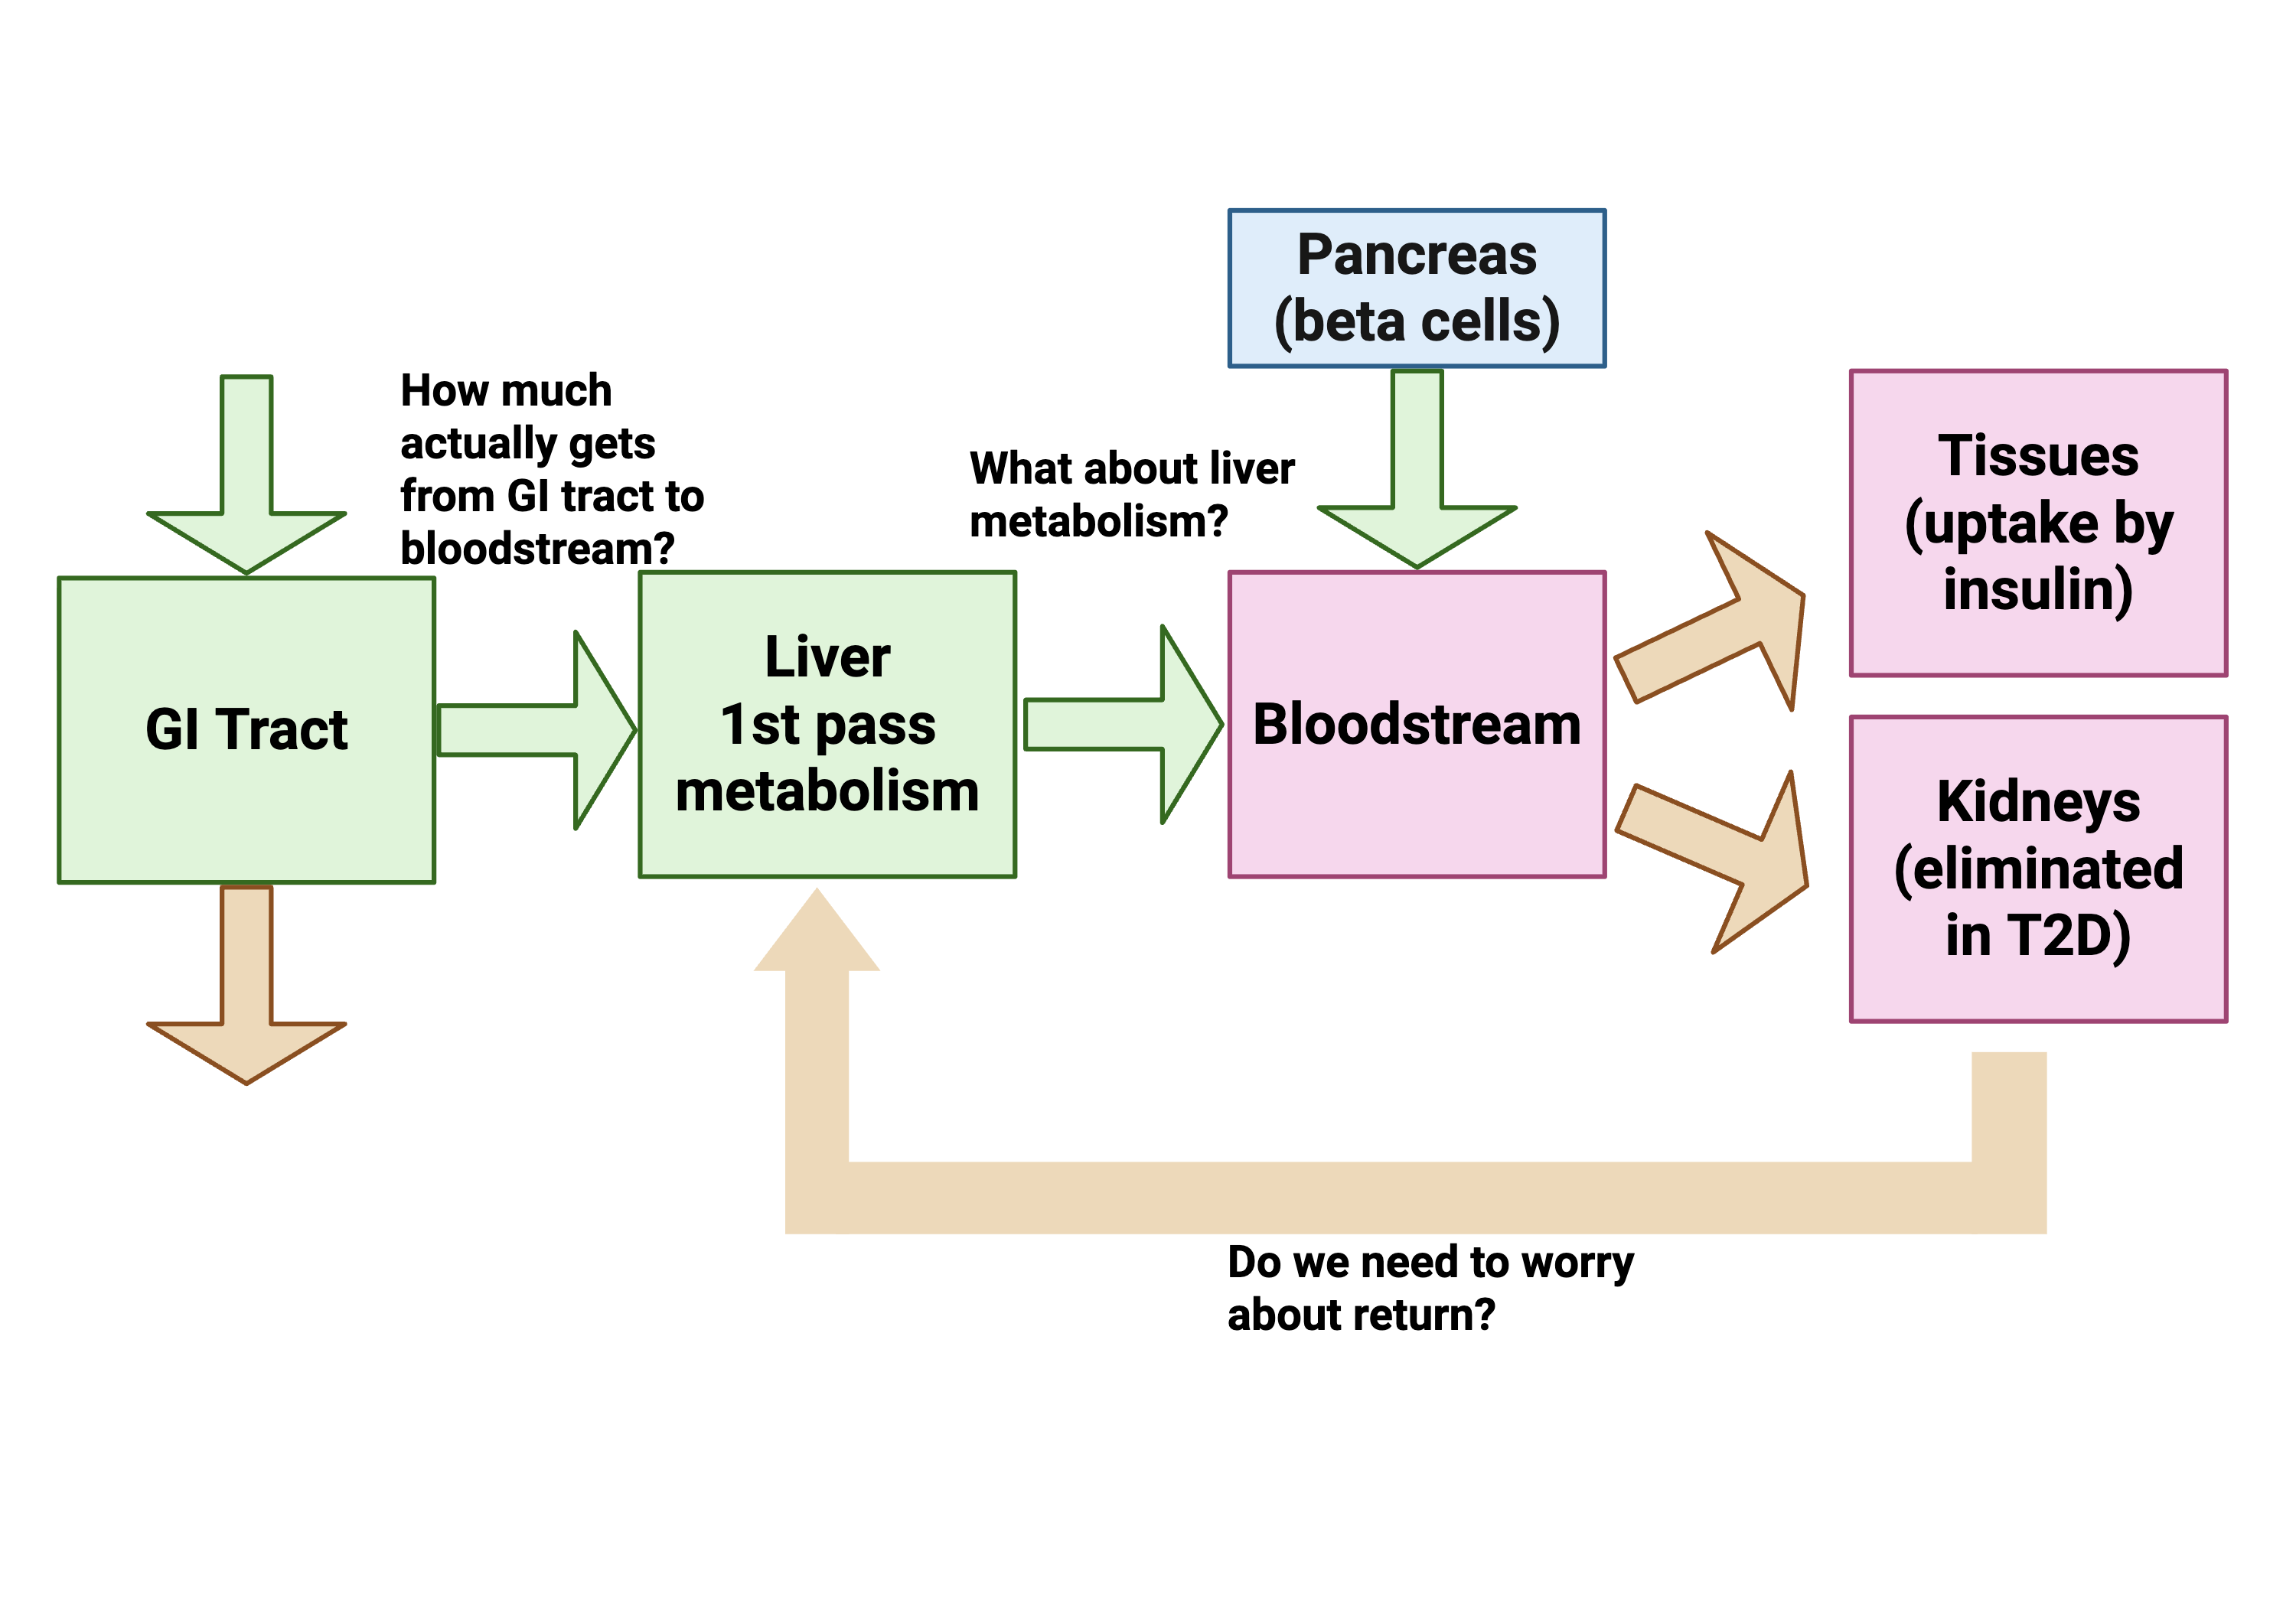

Your PBL#0 assignment will have you continue to work with this expanded model, explore how changing parameters and functions lead to different behaviors, and prepare a results section that would form the basis for a solid PBL report and oral presentation

# PBL#0 assignment

## Homework: Model Extensions and Physiological Interpretation

In this assignment, you will extend the glucose–insulin model developed in class.
Rather than treating the model as “correct,” you will treat it as a *hypothesis* —
something that can be modified, tested, and improved.

Across three problems, you will:
1. Replace a hard threshold with a smooth biological response.
2. Analyze how parameters control system behavior using both time-domain and dose-response analyses.
3. Propose and implement a more physiologically realistic glucose uptake mechanism.

You should prepare your graphs professionally and write high-quality results sections that would be akin to a manuscript. I highly recommend reading [Dr. Caroline Palmer's 'How to write a results section](https://drcarolinepalmer.medium.com/how-to-write-a-results-section-91c5152914ac) for figure and writing assistance.


### Problem 1: From Thresholds to Smooth Biological Responses

In the current model, insulin secretion (or activation) is triggered using an `if` statement,
which creates an abrupt, discontinuous response to glucose.

Real biological systems rarely behave this way. Instead, responses are often:
- graded,
- saturating,
- and smooth.

A common way to model this behavior is with a **Hill function**.

$$f(G) = \frac{G^n}{K^n + G^n}$$
where $G$ is the blood glucose concentration, $K$ is a numerical threshold for glucose levels, and $n$ is a Hill coefficient that corresponds to a steepness of the insulin secretion response. [Alcazar (2019)](https://www.frontiersin.org/journals/endocrinology/articles/10.3389/fendo.2019.00680/full) shows that reasonable parameters for human beta islet cells to be $K = 7.9$ mm and $n = 3.2$

#### Your task

1. Generate a plot of the Hill function for $f(G)$ with appropriate levels and compare to the `if` statement logic we previously used. (1-2 sentences here)
2. Replace this threshold with a Hill function in your ODE solver and generate model simulations for blood glucose. Plot simulations using either the Hill function of `if` logic and describe the differences in responses *quantitatively*. (2-3 sentences)

Feel free to change any parameters as you need to for more realistic results, but be sure to justify your alterations and assumptions.

In [ ]:
##CODE GOES HERE

### Problem 2: How Do Parameters Shape System Behavior?

Model parameters encode physiological assumptions.
In this problem, you will explore how changing parameters affects model predictions.

You will focus on:
- **s**: baseline glucose clearance mediated by insulin (i.e. insulin sensitivity)
- **q**: glucose-mediated insulin secretion

For each parameter ($s$ and $q$):
1. How does increasing the parameter affect glucose dynamics?
2. Does the parameter primarily affect:
   - the *speed* of glucose clearance,
   - the *magnitude* of glucose change,
   - or both?
3. How would you interpret this parameter physiologically?

#### Your task
1. Generate time-series plots for a few different parameters of $s$ **or** $q$ based on your team's interest.
2. Prepare a dose-response plot that looks at a key response in blood glucose dynamics, such as *time to peak, peak glucose, or time to steady state* vs. the changing parameter of interest.
3. A written explanation (5 sentences max) that explains both *qualitative* and *quantitative* findings of this parameter change.

Similarly, you may need to change a parameter to be a constant while others are altered for more realistic results. Again, describe your assumptions and changes to the base model.

In [ ]:
### CODE GOES HERE

### Problem 3: Improving Model Assumptions

In the current model, glucose appears in the bloodstream in a highly simplified way —
effectively as a direct input.

In reality, glucose enters the blood through a multi-step process involving:
- ingestion,
- digestion,
- absorption from the gut,
- and transport into the bloodstream.

In this problem, you will propose and implement a **more physiologically realistic glucose uptake mechanism**.

#### Your task

1. Identify the part of the model where glucose is “injected” directly into the bloodstream.
2. Propose an improved mechanism for glucose uptake.
   Examples include:
   - a delayed input function,
   - a smooth pulse (e.g., Gaussian or exponential),
   - or an additional compartment representing the gut with uptake into bloodstream.

3. Modify the model equations to include your new uptake mechanism.
4. Simulate the updated model and compare results to the original version. (5 sentences max)
5. Describe what is still missing from the model or where assumptions are breaking down. This would be a great paragraph as part of your *Discussion* section for your PBL reports

In [ ]:
### CODE GOES HERE